# Semantic Embeddings with Sentence-BERT

This notebook builds the semantic representation that cross-medium recommendation depends on. It encodes both catalogues into a single 384-dimensional vector space using a pre-trained Sentence-BERT model, so that a course and a book about the same subject sit close together even when their titles share no words at all.

The motivation comes directly from my evaluation of the TF-IDF model. That model showed two failure modes: courses ranked highly because they shared an institution name rather than a subject, and items matched on a single ambiguous word used in different senses. Both follow from measuring word overlap rather than meaning, and this notebook tests whether a semantic representation removes them.

The two catalogues are prepared differently, and section 2 explains why. Courses are encoded from their titles alone, since Coursera names courses after what they teach and no further subject text exists in the dataset. Books are encoded from their title combined with their most-applied community subject tags, because book titles are frequently metaphorical and carry little subject signal on their own.

The notebook produces two embedding matrices, a cross-medium similarity matrix linking every course to every book, and a set of recommendation functions used by the later stages of the project.

In [1]:
# Install the sentence-transformers library 
!pip install sentence-transformers -q

print("Installation complete")

Installation complete


In [2]:
# Silence Hugging Face download progress widgets and info messages
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Semantic embeddings
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Loading the TF-IDF model saved earlier for comparison
import pickle

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [3]:
# Load both filtered catalogues
courses = pd.read_csv('coursera_courses_filtered.csv')
books = pd.read_csv('books_filtered.csv')

print(f"Courses: {len(courses)}")
print(f"Books: {len(books)}")
print(f"Total items to encode: {len(courses) + len(books)}")

print(f"\nFirst 3 course titles:")
for t in courses['name'].head(3):
    print(f"  {t}")

print(f"\nFirst 3 book titles:")
for t in books['title'].head(3):
    print(f"  {t}")

Courses: 336
Books: 593
Total items to encode: 929

First 3 course titles:
  Machine Learning
  Technical Support Fundamentals
  Become a CBRS Certified Professional Installer by Google

First 3 book titles:
  Freakonomics: A Rogue Economist Explores the Hidden Side of Everything (Freakonomics, #1)
  The Tipping Point: How Little Things Can Make a Big Difference
  Outliers: The Story of Success


---
## Preparing the text for each catalogue

The two catalogues need different treatment, and the reason is visible in the titles printed above. Coursera names its courses after what they teach: "Machine Learning", "Technical Support Fundamentals". The title alone states the subject. Book titles frequently do not. "Outliers", "Blink" and "Freakonomics" are marketing titles that carry almost no subject signal, so encoding them alone would give the semantic model very little to work with, and cross-medium matching would fail on the book side.

I therefore enrich each book with its most-applied community tags, using the same tag data my curation filter drew on. Tags describing shelf management rather than subject, such as "to-read" and "owned", are excluded. Courses keep their titles alone, since no further subject text exists in that dataset.

In [4]:
# Load the tag files used earlier in the curation notebook
tags = pd.read_csv('tags.csv')
book_tags = pd.read_csv('book_tags.csv')

# Tags that describe how a reader files a book, not what it is about
shelf_tags = [
    'to-read', 'currently-reading', 'favorites', 'owned', 'books-i-own',
    'to-buy', 'library', 'kindle', 'audiobook', 'audiobooks', 'book-club',
    'default', 'my-books', 'wish-list', 'ebook', 'read', 'owned-books',
    'i-own', 'favourites', 'shelfari-favorites', 'books', 'bookshelf',
    'non-fiction', 'nonfiction'
]

# Keep only tags that describe subject matter
subject_tags = tags[~tags['tag_name'].isin(shelf_tags)]
subject_book_tags = book_tags[book_tags['tag_id'].isin(subject_tags['tag_id'])]

print(f"Total tags in dataset: {len(tags):,}")
print(f"Subject tags after removing shelf labels: {len(subject_tags):,}")

Total tags in dataset: 34,252
Subject tags after removing shelf labels: 34,229


In [5]:
# For each book, take its five most-applied subject tags
top_tags = (
    subject_book_tags
    .merge(subject_tags, on='tag_id')
    .sort_values('count', ascending=False)
    .groupby('goodreads_book_id')
    .head(5)
    .groupby('goodreads_book_id')['tag_name']
    .apply(lambda x: ', '.join(x))
    .reset_index()
    .rename(columns={'tag_name': 'subject_tags'})
)

# Attach the tags to the books table
books = books.merge(top_tags, on='goodreads_book_id', how='left')
books['subject_tags'] = books['subject_tags'].fillna('')

print("Sample books with their subject tags:\n")
for _, row in books.head(5).iterrows():
    print(f"  {row['title'][:55]}")
    print(f"      tags: {row['subject_tags']}\n")

Sample books with their subject tags:

  Freakonomics: A Rogue Economist Explores the Hidden Sid
      tags: science, psychology, sociology, economics, politics

  The Tipping Point: How Little Things Can Make a Big Dif
      tags: business, psychology, sociology, science, economics

  Outliers: The Story of Success
      tags: psychology, economics, self-improvement, success, business

  The Immortal Life of Henrietta Lacks
      tags: science, biography, history, medicine, bookclub

  Blink: The Power of Thinking Without Thinking
      tags: psychology, business, science, self-help, sociology



In [6]:
# Build the text that will be encoded for each catalogue
course_texts = courses['name'].fillna('').tolist()
books['content'] = books['title'].fillna('') + '. ' + books['subject_tags']
book_texts = books['content'].tolist()

print(f"Course texts ready: {len(course_texts)}")
print(f"Book texts ready: {len(book_texts)}")

print(f"\nSample course text:")
print(f"  {course_texts[0]}")

print(f"\nSample book text:")
print(f"  {book_texts[0]}")

print(f"\nAverage text length — courses: {np.mean([len(t) for t in course_texts]):.0f} characters")
print(f"Average text length — books:   {np.mean([len(t) for t in book_texts]):.0f} characters")

Course texts ready: 336
Book texts ready: 593

Sample course text:
  Machine Learning

Sample book text:
  Freakonomics: A Rogue Economist Explores the Hidden Side of Everything (Freakonomics, #1). science, psychology, sociology, economics, politics

Average text length — courses: 41 characters
Average text length — books:   106 characters


---
## Loading the pre-trained model

I use `all-MiniLM-L6-v2`, a Sentence-BERT model trained on over a billion sentence pairs. It maps any piece of text into a 384-dimensional vector positioned so that texts with similar meaning sit close together. I chose it because it produces strong embeddings while remaining small enough to run on a laptop without a GPU, which is one of the non-functional requirements in my Design chapter.

No training takes place here. The model is already trained, and I use it only to convert text into vectors.

In [7]:
# Load the pre-trained Sentence-BERT model
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Model loaded")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")
print(f"Maximum input length: {model.max_seq_length} tokens")

Model loaded
Embedding dimension: 384
Maximum input length: 256 tokens


---
## Encoding both catalogues

Both catalogues pass through the same model, which is what places them in a single shared space. This is the step that makes cross-medium comparison possible: because a course vector and a book vector are produced by the same function, the distance between them is meaningful.

In [8]:
# Encode course titles
print("Encoding courses...")
course_embeddings = model.encode(course_texts, show_progress_bar=False)

# Encode book text
print("Encoding books...")
book_embeddings = model.encode(book_texts, show_progress_bar=False)

print(f"\nCourse embeddings shape: {course_embeddings.shape}")
print(f"Book embeddings shape: {book_embeddings.shape}")
print(f"\nEach item is now represented by {course_embeddings.shape[1]} numbers.")

Encoding courses...
Encoding books...

Course embeddings shape: (336, 384)
Book embeddings shape: (593, 384)

Each item is now represented by 384 numbers.


---
## Sanity check on known items

Before comparing representations, I check that the embeddings behave sensibly on a course whose correct neighbours I already know. If the model is working, the nearest courses to "Machine Learning" should be other machine learning courses.

In [9]:
# Similarity between every pair of courses in the semantic space
course_sim_sbert = cosine_similarity(course_embeddings)

def similar_courses_sbert(course_name, top_k=10):
    """Return the top-K courses most semantically similar to the given course."""
    matches = courses[courses['name'].str.lower() == course_name.lower()]
    if len(matches) == 0:
        return f"Course '{course_name}' not found in catalogue."
    idx = matches.index[0]

    scores = pd.DataFrame({
        'course_index': range(len(courses)),
        'similarity': course_sim_sbert[idx]
    })
    scores = scores[scores['course_index'] != idx]
    scores = scores.nlargest(top_k, 'similarity')

    result = courses.iloc[scores['course_index'].values][['name', 'institution']].copy()
    result['similarity'] = scores['similarity'].round(3).values
    return result.reset_index(drop=True)

print("Semantic neighbours of: Machine Learning\n")
print(similar_courses_sbert("Machine Learning").to_string(index=False))

Semantic neighbours of: Machine Learning

                                               name              institution  similarity
                           Machine Learning for All     University of London       0.756
                   Introduction to Machine Learning          Duke University       0.690
                       Machine Learning with Python                      IBM       0.671
        Machine Learning for Business Professionals             Google Cloud       0.654
    Fundamentals of Machine Learning for Healthcare      Stanford University       0.589
                 Applied Machine Learning in Python   University of Michigan       0.588
              Structuring Machine Learning Projects          DeepLearning.AI       0.575
                   How Google does Machine Learning             Google Cloud       0.571
Machine Learning Foundations: A Case Study Approach University of Washington       0.561
                  Neural Networks and Deep Learning          DeepLea

---
## Comparing TF-IDF against Sentence-BERT

Chapter 5 of my report identified two failure modes in the TF-IDF model: courses ranking on a shared institution rather than a shared subject, and matches driven by a shared surface phrase. This cell places the two representations side by side on the same query so the difference can be seen directly.

In [10]:
# Load the TF-IDF similarity matrix built in the content-based notebook
tfidf_sim = np.load('content_similarity_matrix.npy')

def compare_representations(course_name, top_k=8):
    """Show the top-K neighbours from TF-IDF and Sentence-BERT side by side."""
    idx = courses[courses['name'].str.lower() == course_name.lower()].index[0]

    rows = []
    for matrix in [tfidf_sim, course_sim_sbert]:
        scores = pd.DataFrame({
            'course_index': range(len(courses)),
            'similarity': matrix[idx]
        })
        scores = scores[scores['course_index'] != idx]
        scores = scores.nlargest(top_k, 'similarity')
        names = courses.iloc[scores['course_index'].values]['name'].values
        rows.append([n[:42] for n in names])

    return pd.DataFrame({'TF-IDF': rows[0], 'Sentence-BERT': rows[1]})

print("Query: Machine Learning\n")
print(compare_representations("Machine Learning").to_string())

Query: Machine Learning

                                       TF-IDF                               Sentence-BERT
0  Fundamentals of Machine Learning for Healt                    Machine Learning for All
1  Divide and Conquer, Sorting and Searching,            Introduction to Machine Learning
2                    Machine Learning for All                Machine Learning with Python
3               Introduction to Clinical Data  Machine Learning for Business Professional
4            Introduction to Machine Learning  Fundamentals of Machine Learning for Healt
5  Machine Learning Foundations: A Case Study          Applied Machine Learning in Python
6                     Organizational Analysis       Structuring Machine Learning Projects
7  Probabilistic Graphical Models 1: Represen            How Google does Machine Learning


---
## Sanity check on the books

The same check is applied to the book catalogue. Because book titles carry little subject signal on their own, this also tests whether enriching them with community tags gave the model enough to work with.

In [11]:
# Similarity between every pair of books in the semantic space
book_sim_sbert = cosine_similarity(book_embeddings)

def similar_books_sbert(book_title, top_k=10):
    """Return the top-K books most semantically similar to the given book."""
    matches = books[books['title'].str.contains(book_title, case=False, na=False, regex=False)]
    if len(matches) == 0:
        return f"Book '{book_title}' not found in catalogue."
    idx = matches.index[0]

    scores = pd.DataFrame({
        'book_index': range(len(books)),
        'similarity': book_sim_sbert[idx]
    })
    scores = scores[scores['book_index'] != idx]
    scores = scores.nlargest(top_k, 'similarity')

    result = books.iloc[scores['book_index'].values][['title', 'authors']].copy()
    result['similarity'] = scores['similarity'].round(3).values
    return result.reset_index(drop=True)

print(f"Query book: {books.loc[books['title'].str.contains('Thinking, Fast', na=False), 'title'].values[0]}\n")
print(similar_books_sbert("Thinking, Fast").to_string(index=False))

Query book: Thinking, Fast and Slow

                                                         title                             authors  similarity
                                     The Magic of Thinking Big                   David J. Schwartz       0.738
                 Blink: The Power of Thinking Without Thinking                    Malcolm Gladwell       0.722
                                   The Science of Getting Rich                  Wallace D. Wattles       0.694
                                            Rich Dad, Poor Dad                  Robert T. Kiyosaki       0.692
                                            Think Like a Freak Steven D. Levitt, Stephen J. Dubner       0.688
                                                 How We Decide                        Jonah Lehrer       0.682
                                          The Millionaire Mind                   Thomas J. Stanley       0.669
Nudge: Improving Decisions About Health, Wealth, and Happiness Richard H. T

---
## Cross-medium pairing

This is the component that distinguishes my project from the systems reviewed in Chapter 2. Because courses and books were encoded by the same model into the same space, the similarity between a course vector and a book vector is directly comparable. Given a course, I can therefore retrieve the books that sit closest to it in meaning, without either catalogue needing any shared identifier, shared vocabulary, or overlapping users.

In [12]:
# Similarity between every course and every book
cross_sim = cosine_similarity(course_embeddings, book_embeddings)

print(f"Cross-medium similarity matrix shape: {cross_sim.shape}")
print(f"  {cross_sim.shape[0]} courses x {cross_sim.shape[1]} books")

def books_for_course(course_name, top_k=5):
    """Return the top-K books most semantically related to the given course."""
    matches = courses[courses['name'].str.lower() == course_name.lower()]
    if len(matches) == 0:
        return f"Course '{course_name}' not found in catalogue."
    idx = matches.index[0]

    scores = pd.DataFrame({
        'book_index': range(len(books)),
        'similarity': cross_sim[idx]
    })
    scores = scores.nlargest(top_k, 'similarity')

    result = books.iloc[scores['book_index'].values][['title', 'authors']].copy()
    result['similarity'] = scores['similarity'].round(3).values
    return result.reset_index(drop=True)

# Test on three courses covering different subject areas
for course in ["Machine Learning", "Financial Markets",
               "Learning How to Learn: Powerful mental tools to help you master tough subjects"]:
    print(f"\nBooks recommended for: {course[:55]}\n")
    print(books_for_course(course).to_string(index=False))
    print("-" * 75)

Cross-medium similarity matrix shape: (336, 593)
  336 courses x 593 books

Books recommended for: Machine Learning

                                                                  title                          authors  similarity
The Signal and the Noise: Why So Many Predictions Fail - But Some Don't                      Nate Silver       0.292
                 Dataclysm: Who We Are (When We Think No One's Looking)                 Christian Rudder       0.280
            In the Plex: How Google Thinks, Works, and Shapes Our Lives                      Steven Levy       0.255
                                         A Random Walk Down Wall Street                Burton G. Malkiel       0.232
                                                       How Google Works Eric Schmidt, Jonathan Rosenberg       0.216
---------------------------------------------------------------------------

Books recommended for: Financial Markets

                                                              

---
## Pairing in the reverse direction

The shared space is symmetric, so the same matrix supports the opposite query: given a book a learner has valued, which courses address the same subject. This covers the scenario described by the third persona in my Design chapter, who wants courses matched to the reading she has already done.

In [13]:
def courses_for_book(book_title, top_k=5):
    """Return the top-K courses most semantically related to the given book."""
    matches = books[books['title'].str.contains(book_title, case=False, na=False, regex=False)]
    if len(matches) == 0:
        return f"Book '{book_title}' not found in catalogue."
    idx = matches.index[0]

    scores = pd.DataFrame({
        'course_index': range(len(courses)),
        'similarity': cross_sim[:, idx]
    })
    scores = scores.nlargest(top_k, 'similarity')

    result = courses.iloc[scores['course_index'].values][['name', 'institution']].copy()
    result['similarity'] = scores['similarity'].round(3).values
    return result.reset_index(drop=True)

for title in ["Thinking, Fast", "A Random Walk", "The 7 Habits"]:
    full = books.loc[books['title'].str.contains(title, na=False), 'title'].values[0]
    print(f"\nCourses recommended for: {full[:60]}\n")
    print(courses_for_book(title).to_string(index=False))
    print("-" * 75)


Courses recommended for: Thinking, Fast and Slow

                                                         name                                             institution  similarity
                                           Behavioral Finance                                         Duke University       0.499
Introduction to Neuroeconomics: How the Brain Makes Decisions National Research University Higher School of Economics       0.455
               Entrepreneurship 1: Developing the Opportunity                              University of Pennsylvania       0.385
                        Finance for Non-Finance Professionals                                         Rice University       0.374
                                            Financial Markets                                         Yale University       0.371
---------------------------------------------------------------------------

Courses recommended for: A Random Walk Down Wall Street

                           name    

---
## How well is the book catalogue able to serve the course catalogue

The Machine Learning result above returned a much lower best score than the Financial Markets result, which suggests the strength of a pairing depends on whether the book catalogue contains anything on that subject at all. This cell measures that across the whole catalogue by recording, for every course, the similarity of its single best-matching book.

In [14]:
# For every course, the similarity of its best-matching book
best_match = cross_sim.max(axis=1)

print(f"Best cross-medium match per course:")
print(f"  Mean:   {best_match.mean():.3f}")
print(f"  Median: {np.median(best_match):.3f}")
print(f"  Lowest: {best_match.min():.3f}")
print(f"  Highest:{best_match.max():.3f}")

print(f"\nCourses with a strong book match (above 0.45): "
      f"{(best_match > 0.45).sum()} of {len(courses)} "
      f"({(best_match > 0.45).sum()/len(courses)*100:.1f}%)")
print(f"Courses with a weak best match (below 0.30): "
      f"{(best_match < 0.30).sum()} of {len(courses)} "
      f"({(best_match < 0.30).sum()/len(courses)*100:.1f}%)")

# Which courses are best and worst served by the book catalogue
courses_check = courses.copy()
courses_check['best_book_similarity'] = best_match.round(3)

print(f"\nCourses best served by the book catalogue:")
print(courses_check.nlargest(5, 'best_book_similarity')[['name', 'best_book_similarity']].to_string(index=False))

print(f"\nCourses least served by the book catalogue:")
print(courses_check.nsmallest(5, 'best_book_similarity')[['name', 'best_book_similarity']].to_string(index=False))

Best cross-medium match per course:
  Mean:   0.407
  Median: 0.401
  Lowest: 0.171
  Highest:0.724

Courses with a strong book match (above 0.45): 114 of 336 (33.9%)
Courses with a weak best match (below 0.30): 63 of 336 (18.8%)

Courses best served by the book catalogue:
                                                   name  best_book_similarity
            Entrepreneurship 2: Launching your Start-Up                 0.724
                              Business Model Innovation                 0.721
                         Economics of Money and Banking                 0.687
Successful Negotiation: Essential Strategies and Skills                 0.673
                           Corporate Finance Essentials                 0.671

Courses least served by the book catalogue:
                                                                  name  best_book_similarity
                           Embedded Software and Hardware Architecture                 0.171
Building Scalable Java Micr

---
## Testing against the design personas

The three personas in my Design chapter each describe a specific need. This cell runs one query for each and returns both a course and a book, which is the output the finished system will produce.

In [15]:
def recommend_for_topic(topic, n_courses=3, n_books=3):
    """Given a free-text topic, return the closest courses and books."""
    query_vec = model.encode([topic], show_progress_bar=False)

    c_scores = cosine_similarity(query_vec, course_embeddings).flatten()
    b_scores = cosine_similarity(query_vec, book_embeddings).flatten()

    top_c = courses.iloc[np.argsort(c_scores)[-n_courses:][::-1]][['name', 'institution']].copy()
    top_c['similarity'] = np.sort(c_scores)[-n_courses:][::-1].round(3)

    top_b = books.iloc[np.argsort(b_scores)[-n_books:][::-1]][['title', 'authors']].copy()
    top_b['similarity'] = np.sort(b_scores)[-n_books:][::-1].round(3)

    return top_c.reset_index(drop=True), top_b.reset_index(drop=True)

persona_queries = {
    "Sarah — moving from marketing into data science": "getting started with data science and statistics",
    "Mohammed — preparing for a machine learning exam": "machine learning algorithms and neural networks",
    "Anna — self-taught developer, weak foundations": "computer science fundamentals and programming concepts"
}

for persona, query in persona_queries.items():
    c, b = recommend_for_topic(query)
    print(f"\n{persona}")
    print(f"Query: \"{query}\"\n")
    print("  Courses:")
    print(c.to_string(index=False))
    print("\n  Books:")
    print(b.to_string(index=False))
    print("=" * 78)


Sarah — moving from marketing into data science
Query: "getting started with data science and statistics"

  Courses:
                                                       name                             institution  similarity
                                      What is Data Science?                                     IBM       0.653
                                   Data Science Math Skills                         Duke University       0.634
Introducción a Data Science: Programación Estadística con R Universidad Nacional Autónoma de México       0.595

  Books:
                                                 title          authors  similarity
Dataclysm: Who We Are (When We Think No One's Looking) Christian Rudder       0.458
                           Chaos: Making a New Science     James Gleick       0.351
                                  The Wisdom of Crowds James Surowiecki       0.308

Mohammed — preparing for a machine learning exam
Query: "machine learning algorithms a

---
## Testing the subject areas the catalogue serves best

The coverage analysis showed that business and economics courses have the strongest book matches, while hands-on programming courses have the weakest. This cell tests that directly by running free-text queries across several subject areas and reporting the strength of the best match in each.

In [16]:
# Test coverage across a range of subject areas
test_topics = [
    "digital marketing and social media strategy",
    "starting and running a business",
    "personal finance and investing",
    "leadership and managing a team",
    "data analysis and statistics",
    "python programming and software development",
    "cloud computing and system administration"
]

print(f"{'Topic':<48}{'Best course':>12}{'Best book':>12}")
print("-" * 72)

for topic in test_topics:
    q = model.encode([topic], show_progress_bar=False)
    c_best = cosine_similarity(q, course_embeddings).max()
    b_best = cosine_similarity(q, book_embeddings).max()
    print(f"{topic:<48}{c_best:>12.3f}{b_best:>12.3f}")

print("\nExample — the strongest business topic in detail:\n")
c, b = recommend_for_topic("starting and running a business")
print("  Courses:")
print(c.to_string(index=False))
print("\n  Books:")
print(b.to_string(index=False))

Topic                                            Best course   Best book
------------------------------------------------------------------------
digital marketing and social media strategy            0.808       0.511
starting and running a business                        0.680       0.597
personal finance and investing                         0.685       0.665
leadership and managing a team                         0.689       0.659
data analysis and statistics                           0.684       0.389
python programming and software development            0.829       0.445
cloud computing and system administration              0.680       0.330

Example — the strongest business topic in detail:

  Courses:
                                          name                    institution  similarity
   Entrepreneurship 2: Launching your Start-Up     University of Pennsylvania       0.680
Entrepreneurship 1: Developing the Opportunity     University of Pennsylvania       0.554
          

---
## Visualizing cross-medium coverage

A histogram of the best available book match for every course shows how coverage is distributed across the catalogue rather than only at the extremes.

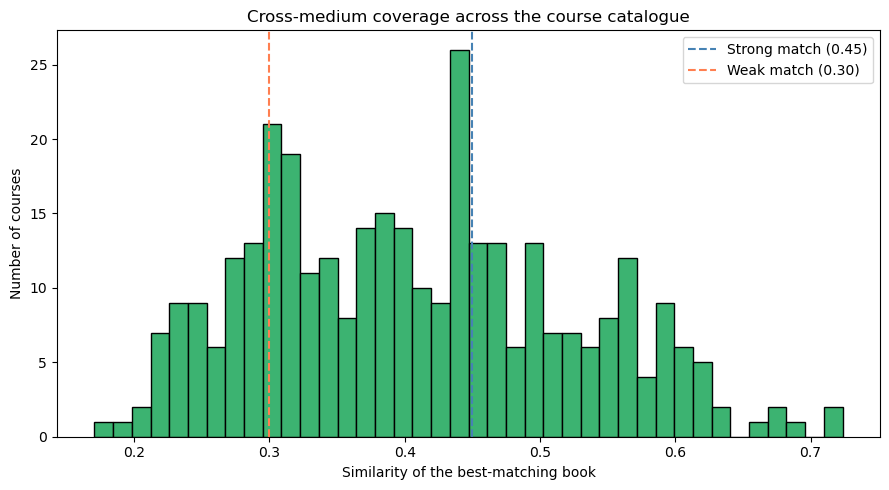

Strong (above 0.45): 114 courses
Moderate (0.30-0.45): 159 courses
Weak (below 0.30): 63 courses


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(best_match, bins=40, color='mediumseagreen', edgecolor='black')
ax.set_xlabel('Similarity of the best-matching book')
ax.set_ylabel('Number of courses')
ax.set_title('Cross-medium coverage across the course catalogue')
ax.axvline(0.45, color='steelblue', linestyle='--', label='Strong match (0.45)')
ax.axvline(0.30, color='coral', linestyle='--', label='Weak match (0.30)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Strong (above 0.45): {(best_match > 0.45).sum()} courses")
print(f"Moderate (0.30-0.45): {((best_match >= 0.30) & (best_match <= 0.45)).sum()} courses")
print(f"Weak (below 0.30): {(best_match < 0.30).sum()} courses")

---
## Applying a confidence threshold

The coverage analysis showed that some courses have no closely related book in the catalogue. Returning the nearest available book regardless of its score would present a poor match as though it were a good one. I therefore apply a threshold: below a similarity of 0.30 the system reports that no strongly related item was found, rather than returning a weak result.

In [18]:
def books_for_course_confident(course_name, top_k=5, threshold=0.30):
    """Return related books, or report honestly when none is close enough."""
    matches = courses[courses['name'].str.lower() == course_name.lower()]
    if len(matches) == 0:
        return f"Course '{course_name}' not found in catalogue."
    idx = matches.index[0]

    scores = pd.DataFrame({
        'book_index': range(len(books)),
        'similarity': cross_sim[idx]
    })
    scores = scores[scores['similarity'] >= threshold]

    if len(scores) == 0:
        return (f"No strongly related book found for '{course_name}'. "
                f"Best available similarity was {cross_sim[idx].max():.3f}, "
                f"below the {threshold} threshold.")

    scores = scores.nlargest(top_k, 'similarity')
    result = books.iloc[scores['book_index'].values][['title', 'authors']].copy()
    result['similarity'] = scores['similarity'].round(3).values
    return result.reset_index(drop=True)

# A course the catalogue serves well, and one it does not
for course in ["Financial Markets", "Using Python to Access Web Data"]:
    print(f"\nCourse: {course}\n")
    result = books_for_course_confident(course)
    if isinstance(result, str):
        print(result)
    else:
        print(result.to_string(index=False))
    print("-" * 75)


Course: Financial Markets

                                                                              title                     authors  similarity
                                                     A Random Walk Down Wall Street           Burton G. Malkiel       0.661
                              The Ascent of Money: A Financial History of the World              Niall Ferguson       0.575
One Up On Wall Street: How To Use What You Already Know To Make Money In The Market Peter Lynch, John Rothchild       0.554
         Fooled by Randomness: The Hidden Role of Chance in Life and in the Markets       Nassim Nicholas Taleb       0.545
                                                   Flash Boys: A Wall Street Revolt             Michael   Lewis       0.519
---------------------------------------------------------------------------

Course: Using Python to Access Web Data

No strongly related book found for 'Using Python to Access Web Data'. Best available similarity was 0.211, bel

---
## Saving the model artifacts

The two embedding matrices and the enriched book table are saved so that the hybrid model, the evaluation and the web application can load them without re-encoding. The similarity matrices are not saved, since they are derived from the embeddings and are inexpensive to recompute.

In [19]:
# Save both embedding matrices
np.save('course_embeddings.npy', course_embeddings)
np.save('book_embeddings.npy', book_embeddings)

# Save the books table with the subject tags and the encoded text
books.to_csv('books_with_content.csv', index=False)

print("Saved: course_embeddings.npy")
print("Saved: book_embeddings.npy")
print("Saved: books_with_content.csv")

print(f"\nCourse embeddings: {course_embeddings.shape}")
print(f"Book embeddings:   {book_embeddings.shape}")

Saved: course_embeddings.npy
Saved: book_embeddings.npy
Saved: books_with_content.csv

Course embeddings: (336, 384)
Book embeddings:   (593, 384)


---
## Summary

This notebook produced the semantic representation the rest of the project depends on, and established four findings.

Sentence-BERT resolves the lexical failure modes identified in my earlier evaluation, returning eight relevant courses out of eight against TF-IDF's four, and retrieving related items that share no vocabulary with the query at all.

Cross-medium pairing works in both directions using a single shared space, with no identifier, vocabulary or user overlap between the two catalogues. This is the component that distinguishes the project from the systems reviewed in Chapter 2.

Coverage is uneven and now measured: 33.9% of courses have a strong book match and 18.8% a weak one, with business and economics served well and hands-on programming served poorly. This reflects the composition of the book dataset rather than any limitation of the matching method, and the confidence threshold added above means the system reports when it has nothing suitable rather than returning a weak result.

Broad topic queries produce substantially better book matches than narrow course titles, which favours the deployed interface, where users type a general topic.

The next stage combines these semantic scores with the collaborative filtering and popularity models into a single hybrid ranking.